# Documentation

This code calculates the normalized gross moist stability (nGMS) following Inoue & Back (2015).

# Imports

In [1]:
%load_ext autoreload
%autoreload 2

print("Loading imports...")
from config import *

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Data analysis
import glob
import os
import sys
from datetime import datetime, timedelta
import copy
import cftime

# Plotting
import matplotlib.pyplot as plt
import numpy as np
import scipy
import scipy.signal as signal
from scipy.stats import t
import xarray as xr
import xrft
from scipy.optimize import curve_fit
import random

# Cartopy
from cartopy import crs as ccrs
from cartopy import feature as cf
from cartopy import util as cutil
from matplotlib import colors as mcolors
from matplotlib import ticker as mticker
from matplotlib.gridspec import GridSpec
import seaborn as sns

# import colormaps as cmaps
sys.path.insert(0, "/glade/u/home/sressel/auxiliary_functions/")
import mjo_mean_state_diagnostics as mjo
from bmh_colors import bmh_colors
from one_two_one_filter import one_two_one_filter
from rounding_functions import round_out
from tick_labeller import tick_labeller
from standardize_data import standardize_data

from processing_functions import time_filter_data, mjo_filter_data
from load_aquaplanet_data import *

print("Imports loaded")

Loading imports...
Imports loaded


# Specify parameters

In [2]:
# Set latitude bounds
LATITUDE_SOUTH = -30
LATITUDE_NORTH = 30
latitude_subset_bounds = slice(LATITUDE_SOUTH, LATITUDE_NORTH)

# Set central longitude
CENTRAL_LONGITUDE = 0

# Set longitude bounds
LONGITUDE_MIN = 0
LONGITUDE_MAX = 360

# Set time bounds
missing_days = [
    cftime.DatetimeNoLeap(7, 2, 5, 0, 0, 0, 0, has_year_zero=True),
    cftime.DatetimeNoLeap(7, 2, 6, 0, 0, 0, 0, has_year_zero=True),
    cftime.DatetimeNoLeap(7, 2, 7, 0, 0, 0, 0, has_year_zero=True),
]

START_TIME = cftime.DatetimeNoLeap(3, 1, 3, 0, 0, 0, 0, has_year_zero=True)
END_TIME = cftime.DatetimeNoLeap(13, 1, 3, 0, 0, 0, 0, has_year_zero=True)
# END_TIME = cftime.DatetimeNoLeap(3, 1, 8, 0, 0, 0, 0, has_year_zero=True)
first_half_subset_bounds = slice(START_TIME, missing_days[0] - timedelta(days=1))
second_half_subset_bounds = slice(missing_days[-1] + timedelta(days=1), END_TIME)

# Cut-off periods for intraseasonal filtering
INTRASEASONAL_LOWCUT = 100
INTRASEASONAL_HIGHCUT = 20
frequency_subset_bounds = slice(INTRASEASONAL_LOWCUT, INTRASEASONAL_HIGHCUT)

# Cut-off wavenumbers for MJO-filtering
LARGE_SCALE_CUTOFF = 1
SMALL_SCALE_CUTOFF = 3
wavenumber_bounds = slice(LARGE_SCALE_CUTOFF, SMALL_SCALE_CUTOFF)

# Column-integrated bounds
LOWER_LEVEL_PRESSURE = 950
UPPER_LEVEL_PRESSURE = 100
pressure_subset_bounds = slice(UPPER_LEVEL_PRESSURE, LOWER_LEVEL_PRESSURE)

In [3]:
def beta_column_integrate(pressure_array, variable, surface_pressure, pbot, ptop):
    """
    Perform vertical integration of a variable using Trenberth (1991) beta factors.

    This function computes the vertical integral of an atmospheric variable
    using pressure levels and surface pressure, accounting for partial layer
    contributions via the beta factor method described by Trenberth (1991).

    Parameters
    ----------
    pressure_array : xarray.DataArray
        A 4D array of pressure values with dimensions (time, lat, lon, index),
        where `index` refers to the midpoint of pressure layers (odd-indexed).

    variable : xarray.DataArray
        A 4D array of the variable to be integrated, with dimensions
        (time, lat, lon, lev), where `lev` matches the vertical structure
        of `pressure_array` (e.g., pressure levels).

    surface_pressure : xarray.DataArray
        A 3D array (time, lat, lon) of surface pressure values.

    pbot : float
        Bottom pressure level (e.g., 100000 Pa for surface).

    ptop : float
        Top pressure level for integration. Layers above this will be excluded.

    Returns
    -------
    column_integrated_variable : xarray.DataArray
        A 3D array (time, lat, lon) of the vertically integrated variable
        in units adjusted by the factor (1 / 9.81), representing integration
        over pressure coordinates.

    Notes
    -----
    - The function constructs intermediate pressure levels at layer boundaries
      using the input `pressure_array`, and computes thicknesses and beta
      weighting factors accordingly.
    - The integration accounts for whether each layer is fully or partially
      beneath the surface using the surface pressure and beta factor.
    - Any layers with pressure less than `ptop` are excluded from the integration.

    References
    ----------
    Trenberth, K. E. (1991). Climate diagnostics from global analyses:
    Conservation of mass in ECMWF analyses. Journal of Climate, 4(7), 707–722.
    """

    # Convert the pressure array to be bottom-to-top, and to have index labels instead of level labels
    pressure_array = pressure_array.transpose(..., "lev")
    pressure_array = pressure_array.isel(lev=slice(None, None,-1))
    pressure_array = pressure_array.assign_coords(lev=("lev", np.arange(1, 2*len(pressure_array.lev), 2)))
    pressure_array = pressure_array.rename({'lev':'index'})

    fill_value = 0

    original_shape = list(pressure_array.shape)
    original_dims = list(pressure_array.dims)
    original_coords = pressure_array.coords

    # Modify shape: extend the last dimension by 1
    extended_shape = original_shape.copy()
    extended_shape[-1] += 1

    # Create extended coordinates for the last dimension
    last_dim = original_dims[-1]
    last_coord = original_coords[last_dim].values
    extended_last_coord = np.arange(0, 2*len(pressure_array.index)+2, 2)

    # Create a dict of coordinates, extending only the last dimension
    extended_coords = {
        dim: (original_coords[dim].values if dim != last_dim else extended_last_coord)
        for dim in original_dims
    }

    # Create the data with desired fill_value (e.g. zeros)
    intermediate_levels = xr.DataArray(
        data = np.full(extended_shape, fill_value, dtype=pressure_array.dtype),
        dims = pressure_array.dims,
        coords = extended_coords
    )

    # # Calculate the intermediate pressure levels
    # intermediate_levels = xr.DataArray(
    #     data=np.zeros((
    #         len(pressure_array.time),
    #         len(pressure_array.lat),
    #         len(pressure_array.lon),
    #         len(pressure_array.index)+1
    #     )),
    #     # dims=["time", "lat", "lon", "index"],
    #     dims=[*pressure_array.dims]
    #     coords={
    #         'time': pressure_array.time,
    #         'lat': pressure_array.lat,
    #         'lon': pressure_array.lon,
    #         'index': np.arange(0, 2*len(pressure_array.index)+2, 2)
    #     }
    # )

    intermediate_levels[..., 0] = pbot*np.ones_like(surface_pressure.values)
    intermediate_levels[..., 1:-1] = 0.5*(pressure_array[..., :-1].values + pressure_array[..., 1:].values)
    intermediate_levels[..., -1] = np.zeros_like(surface_pressure.values)

    # Calculate the thickness of each layer
    pressure_jminus1 = intermediate_levels[..., :-1].values
    pressure_jplus1 = intermediate_levels[..., 1:].values
    layer_thickness = xr.zeros_like(pressure_array)
    layer_thickness[..., :] = pressure_jminus1 - pressure_jplus1

    # Calculate the Trenberth beta factors
    reshaped_surface_pressure = surface_pressure.expand_dims(
        dim={"index": pressure_array.index},
        axis=surface_pressure.ndim
    )

    lower_one_condition = (pressure_jminus1 < reshaped_surface_pressure)
    lower_zero_condition = (pressure_jplus1 > reshaped_surface_pressure)
    lower_beta = xr.where(
        lower_one_condition, 1,
        xr.where(
            lower_zero_condition, 0, (
                (reshaped_surface_pressure - pressure_jplus1)
                / (pressure_jminus1 - pressure_jplus1)
            )
        )
    )

    upper_one_condition = (pressure_jplus1 > ptop)
    upper_zero_condition = (pressure_jminus1 < ptop)
    upper_beta = xr.where(
        upper_one_condition, 1,
        xr.where(
            upper_zero_condition, 0, (
                (pressure_jminus1 - ptop)
                / (pressure_jminus1 - pressure_jplus1)
            )
        )
    )

    # Re-order and label the variable to be integrated
    relabelled_variable = variable.isel(lev=slice(None, None, -1))
    relabelled_variable = relabelled_variable.assign_coords(lev=("lev", np.arange(1, 2*len(pressure_array.index), 2)))
    relabelled_variable = relabelled_variable.rename({'lev': 'index'})

    # Calculate the vertical integral
    column_integrated_variable = (1/9.8)*(
        lower_beta*relabelled_variable*layer_thickness*upper_beta
        # lower_beta*relabelled_variable*layer_thickness*
    ).sum(dim='index')
    return column_integrated_variable


def vertical_pressure_gradient(input_variable, input_pressure_array, units='hPa'):
    """
    Calculate the vertical pressure gradient of a variable using finite differences.

    Parameters
    ----------
    input_variable : xarray.DataArray
        The variable for which the vertical pressure gradient is to be calculated.
        Must include a vertical dimension named 'lev'.

    input_pressure_array : xarray.DataArray
        The pressure values corresponding to each vertical level. Must have the
        same shape and dimensions as `input_variable`, including the 'lev' dimension.

    Returns
    -------
    xarray.DataArray
        The vertical gradient of `input_variable` with respect to pressure,
        with the same dimensions and shape as the input.

    Notes
    -----
    - The gradient is computed using:
        - Forward difference at the bottom boundary (lev=0)
        - Central difference for interior levels (1 <= lev <= N-2)
        - Backward difference at the top boundary (lev=N-1)
    - Assumes pressure decreases with height (as in atmospheric applications).
    """

    # Reorient the input data so that the vertical level dimension 'lev' is last
    variable = input_variable.transpose(..., "lev")
    pressure_array = input_pressure_array.transpose(..., "lev")

    # Create an output array of zeros with the same shape as the input variable
    vertical_gradient = xr.zeros_like(variable)

    # Compute the forward difference for the bottom-most level (lev=0)
    vertical_gradient[..., 0] = (
        (variable[..., 1].values - variable[..., 0].values)
        / (pressure_array[..., 1].values - pressure_array[..., 0].values)
    )

    # Compute the central difference for interior levels (lev=1 to lev=-2)
    vertical_gradient[..., 1:-1] = (
        (variable[..., 2:].values - variable[..., :-2].values)
        / (pressure_array[..., 2:].values - pressure_array[..., :-2].values)
    )

    # Compute the backward difference for the top-most level (lev=-1)
    vertical_gradient[..., -1] = (
        (variable[..., -1].values - variable[..., -2].values)
        / (pressure_array[..., -1].values - pressure_array[..., -2].values)
    )

    # Revert to the original dimension ordering of the input variable
    output_vertical_gradient = vertical_gradient.transpose(*input_variable.dims)

    if units == 'hPa':
        output_vertical_gradient /= 100

    return output_vertical_gradient

# Calculate nGMS constituents

In [5]:
# save_column_integrated_data = True

# # Initialize arrays for budget variables
# column_horizontal_MSE_advection = {}
# column_vertical_MSE_advection = {}
# column_vertical_DSE_advection = {}

# n_calculations = 3

# variables_loaded = {}
# for exp_index, experiment in enumerate(experiments_list):

#     print(f"{'-'*str_width}")
#     print(f"{f'Loading {experiment} data...':<{str_width}}")
#     print(f"{'-'*str_width}")
#     variable_data_files = sorted(glob.glob(
#         rf"{data_directory}/{experiment}/daily_model-level_data/*.nc"
#     ))
#     for index, file in enumerate(variable_data_files):
#         variable_data = xr.open_dataarray(file)
#         print(f"{f'({index+1}/{len(variable_data_files)}) {variable_data.name}...':<{str_width-1}}", end="")
#         variables_loaded[variable_data.name] = variable_data.sel(time=slice(START_TIME, END_TIME))
#         print(rf"{'✔':>1}")
#     print(f"{'-'*str_width}")

#     recalculate_budgets = True

#     non_timed_data =  xr.open_dataset(
#         rf"/glade/campaign/univ/uwas0114/SST_AQP3_Qobs_27_-4K_3h_10y/atm/hist/SST_AQP3_Qobs_27_-4K_3h_20y_new2.cam.h1.0001-02-16-43200.nc"
#     )

#     if recalculate_budgets:
#         print(f"{'Pressure Array...':<{str_width-1}}", end="")
#         lower_level_pressure = 1100.*100.
#         # upper_level_pressure = 100.*100.
#         surface_pressure = variables_loaded['PS']
#         pressure_array = non_timed_data['hyam']*non_timed_data['P0'] + non_timed_data['hybm']*surface_pressure
#         pressure_array = pressure_array.transpose("time", "lev", "lat", "lon")
#         print(rf"{'✔':>1}")

#         time_mean_temperature = variables_loaded['T'].mean(dim=['time'])
#         temperature_minimum_index = time_mean_temperature.argmin('lev')
#         temperature_minimum_pressure_level = pressure_array.mean(dim='time').transpose("lev", ...)[temperature_minimum_index].mean(dim=['lat', 'lon'])
#         upper_level_pressure = temperature_minimum_pressure_level.values

#         print(f"{'Moist Static Energy...':<{str_width-1}}", end="")
#         GRAVITY = 9.8                        #  m/s^2
#         SPECIFIC_HEAT = 1005.7               #  J/Kg*K ; specific heat at constant pressure for dry air
#         HEAT_OF_VAPORIZATION = 2.501e6       #  [J/kg]=[m2/s2]  Latent Heat of Vaporization at 0
#         HEAT_OF_FUSION = 3.337e5             # [J/kg]=[m2/s2]  Latent Heat of Sublimation at 0
#         dry_static_energy = (
#             + SPECIFIC_HEAT*variables_loaded['T']
#             + GRAVITY*variables_loaded['Z3']
#         )
#         dry_static_energy.name = 'Dry Static Energy'
#         dry_static_energy.attrs['units'] = r"J kg$^{-2}$"

#         moist_static_energy = (
#             HEAT_OF_VAPORIZATION*variables_loaded['Q']
#             - HEAT_OF_FUSION*variables_loaded['CLDICE']
#             + SPECIFIC_HEAT*variables_loaded['T']
#             + GRAVITY*variables_loaded['Z3']
#         )
#         moist_static_energy.name = 'Moist Static Energy'
#         moist_static_energy.attrs['units'] = r"J kg$^{-2}$"
#         print(rf"{'✔':>1}")


#         print(f"{'Zonal Advection...':<{str_width-1}}", end="")
#         zonal_MSE_gradient = (
#             (180/np.pi)
#             * moist_static_energy.differentiate('lon')
#             / (EARTH_RADIUS*np.cos(np.deg2rad(moist_static_energy.lat)))
#         )
#         zonal_advection = variables_loaded['U']*zonal_MSE_gradient
#         zonal_advection.name = 'Zonal Advection'
#         zonal_advection.attrs['units'] = r"J kg$^{-2}$ s$^{-1}$"
#         print(rf"{'✔':>1}")

#         print(f"{'Meridional Advection...':<{str_width-1}}", end="")
#         meridional_MSE_gradient = (
#             (180/np.pi)
#             * moist_static_energy.differentiate('lat')
#             / EARTH_RADIUS
#         )

#         meridional_advection = variables_loaded['V'] * meridional_MSE_gradient
#         meridional_advection.name = 'Meridional Advection'
#         meridional_advection.attrs['units'] = r"J kg$^{-2}$ s$^{-1}$"
#         print(rf"{'✔':>1}")

#         horizontal_MSE_advection = zonal_advection + meridional_advection
#         horizontal_MSE_advection.name = 'Horizontal Advection'
#         horizontal_MSE_advection.attrs['units'] = r"J kg$^{-2}$ s$^{-1}$"

#         print(f"{'Vertical MSE Advection...':<{str_width-1}}", end="")
#         # vertical_MSE_gradient = (1/100)*moist_static_energy.differentiate('lev')
#         vertical_MSE_gradient = xr.zeros_like(moist_static_energy)
#         vertical_MSE_gradient[:, 0] = (
#             (moist_static_energy[:, 1].values - moist_static_energy[:, 0].values)
#             / (pressure_array[:, 1].values - pressure_array[:, 0].values)
#         )
#         vertical_MSE_gradient[:, 1:-1] = (
#             (moist_static_energy[:, 2:].values - moist_static_energy[:, :-2].values)
#             / (pressure_array[:, 2:].values - pressure_array[:, :-2].values)
#         )
#         vertical_MSE_gradient[:, -1] = (
#             (moist_static_energy[:, -1].values - moist_static_energy[:, -2].values)
#             / (pressure_array[:, -1].values - pressure_array[:, -2].values)
#         )

#         vertical_MSE_advection = variables_loaded['OMEGA'] * vertical_MSE_gradient
#         vertical_MSE_advection.name = 'Vertical MSE Advection'
#         vertical_MSE_advection.attrs['units'] = r"J kg$^{-2}$ s$^{-1}$"
#         print(rf"{'✔':>1}")

#         print(f"{'Vertical DSE Advection...':<{str_width-1}}", end="")
#         # vertical_MSE_gradient = (1/100)*moist_static_energy.differentiate('lev')
#         vertical_DSE_gradient = xr.zeros_like(dry_static_energy)
#         vertical_DSE_gradient[:, 0] = (
#             (dry_static_energy[:, 1].values - dry_static_energy[:, 0].values)
#             / (pressure_array[:, 1].values - pressure_array[:, 0].values)
#         )
#         vertical_DSE_gradient[:, 1:-1] = (
#             (dry_static_energy[:, 2:].values - dry_static_energy[:, :-2].values)
#             / (pressure_array[:, 2:].values - pressure_array[:, :-2].values)
#         )
#         vertical_DSE_gradient[:, -1] = (
#             (dry_static_energy[:, -1].values - dry_static_energy[:, -2].values)
#             / (pressure_array[:, -1].values - pressure_array[:, -2].values)
#         )

#         vertical_DSE_advection = variables_loaded['OMEGA'] * vertical_DSE_gradient
#         vertical_DSE_advection.name = 'Vertical DSE Advection'
#         vertical_DSE_advection.attrs['units'] = r"J kg$^{-2}$ s$^{-1}$"
#         print(rf"{'✔':>1}")

#         print(f"{'Column integrating...':<{str_width-1}}", end="")
#         # Horizontal MSE Advection
#         column_horizontal_MSE_advection[experiment] = beta_column_integrate(
#             pressure_array,
#             horizontal_MSE_advection,
#             surface_pressure,
#             lower_level_pressure,
#             upper_level_pressure
#         )
#         column_horizontal_MSE_advection[experiment].name = 'Horizontal MSE Advection'
#         column_horizontal_MSE_advection[experiment].attrs = {}
#         column_horizontal_MSE_advection[experiment].attrs['long_name'] = "Horizontal of Moist Static Energy"
#         column_horizontal_MSE_advection[experiment].attrs['math_name'] = r"$\langle$$\vec{v} \nabla$h$\rangle$"
#         column_horizontal_MSE_advection[experiment].attrs['units'] = r"W m$^{-2}$"

#         # Vertical MSE Advection
#         column_vertical_MSE_advection[experiment] = beta_column_integrate(
#             pressure_array,
#             vertical_MSE_advection,
#             surface_pressure,
#             lower_level_pressure,
#             upper_level_pressure
#         )
#         column_vertical_MSE_advection[experiment].name = 'Vertical MSE Advection'
#         column_vertical_MSE_advection[experiment].attrs = {}
#         column_vertical_MSE_advection[experiment].attrs['long_name'] = "Vertical Advection of Moist Static Energy"
#         column_vertical_MSE_advection[experiment].attrs['math_name'] = r"$-\langle$$ω \partial_{p}$h$\rangle$"
#         column_vertical_MSE_advection[experiment].attrs['units'] = r"W m$^{-2}$"

#         # Vertical MSE Advection
#         column_vertical_DSE_advection[experiment] = beta_column_integrate(
#             pressure_array,
#             vertical_DSE_advection,
#             surface_pressure,
#             lower_level_pressure,
#             upper_level_pressure
#         )
#         column_vertical_DSE_advection[experiment].name = 'Vertical DSE Advection'
#         column_vertical_DSE_advection[experiment].attrs = {}
#         column_vertical_DSE_advection[experiment].attrs['long_name'] = "Vertical Advection of Dry Static Energy"
#         column_vertical_DSE_advection[experiment].attrs['math_name'] = r"$-\langle$$ω \partial_{p}$d$\rangle$"
#         column_vertical_DSE_advection[experiment].attrs['units'] = r"W m$^{-2}$"
#         print(rf"{'✔':>1}")

# GMS_variables = {
#     'Horizontal MSE Advection': column_horizontal_MSE_advection,
#     'Vertical MSE Advection': column_vertical_MSE_advection,
#     'Vertical DSE Advection': column_vertical_DSE_advection,
# }

# print("Concatenating along experiment axis...")
# print(f"{'-'*str_width}")
# multi_experiment_GMS_variables = {}
# for index, GMS_variable in enumerate(GMS_variables):
#     print(f"{f'({index+1}/{len(GMS_variables)}) {GMS_variable}...':<{str_width-1}}", end="")
#     multi_experiment_GMS_variables[GMS_variable] = xr.concat(
#         [GMS_variables[GMS_variable][experiment] for experiment in experiments_list],
#         dim=experiments_list
#     )
#     multi_experiment_GMS_variables[GMS_variable] = multi_experiment_GMS_variables[GMS_variable].rename(
#         {"concat_dim": "experiment"}
#     )
#     print(rf"{'✔':>1}")

# if save_column_integrated_data:
#     print(f"{'Saving budget terms':^{str_width}}")
#     print(f"{'='*str_width}")

#     for index, (variable_name, variable_data) in enumerate(multi_experiment_GMS_variables.items()):
#         print(f"{f'({index+1}/{len(multi_experiment_GMS_variables)}) {variable_name}...':<{str_width-1}}", end="")

#         filename = f"{data_directory}/MSE_budget_terms/daily_model-level_data/multi_experiment_{variable_name.lower().replace(' ', '_')}.nc"
#         if os.path.exists(filename):
#             # Prompt user for confirmation
#             # response = input(f"\nFile '{filename}' already exists. Overwrite? (y/n): ").strip().lower()
#             response = 'y'
#             if response == 'y':
#                 os.remove(filename)  # Delete the existing file
#                 variable_data.to_netcdf(filename)  # Save the new file
#                 print(rf"{'✔ (overwritten)':>1}")
#             else:
#                 print(rf"{'✘ (skipped)':>1}")
#         else:
#             variable_data.to_netcdf(filename)  # Save the new file
#             print(rf"{'✔':>1}")
# else:
#     print(f"{'Not saving budget terms':<{str_width}}")

# print(f"{'='*str_width}")
# print("Finished")

# Load data

In [4]:
multi_experiment_GMS_variables = {}
for variable_name in [
    'Horizontal MSE Advection',
    'Vertical MSE Advection',
    'Vertical DSE Advection',
]:
    multi_experiment_GMS_variables[variable_name] = xr.load_dataset(
        f"{data_directory}/MSE_budget_terms/daily_model-level_data/multi_experiment_{variable_name.lower().replace(' ', '_')}.nc"
    )[variable_name].drop_sel(time=missing_days, errors='ignore')
    multi_experiment_GMS_variables[variable_name].name = variable_name

multi_experiment_GMS_variables['Total MSE Advection'] = (
    multi_experiment_GMS_variables['Vertical MSE Advection']
    + multi_experiment_GMS_variables['Horizontal MSE Advection']
)

## Intraseasonally Filter GMS Variables

In [5]:
multi_experiment_intraseasonally_filtered_GMS_variables = {}

print(f"{f'Filtering variables...':^{str_width}}")
print(f"{'='*str_width}")
for index, (variable_name, variable_data) in enumerate(multi_experiment_GMS_variables.items()):
    print(f"{f'({index+1}/{len(multi_experiment_GMS_variables)}) {variable_name}...':<{str_width-1}}", end="")
    multi_experiment_intraseasonally_filtered_GMS_variables[variable_name] = {}
    for experiment in experiments_list:
        first_half = time_filter_data(variable_data.sel(
            experiment=experiment,
            time=first_half_subset_bounds
        ), slice(100, 20))
        second_half = time_filter_data(variable_data.sel(
            experiment=experiment,
            time=second_half_subset_bounds
        ), slice(100, 20))

        multi_experiment_intraseasonally_filtered_GMS_variables[variable_name][experiment] = xr.concat(
            [first_half, second_half], dim='time'
        ).drop_sel(time=missing_days, errors='ignore')

    multi_experiment_intraseasonally_filtered_GMS_variables[variable_name] = xr.concat(
        [multi_experiment_intraseasonally_filtered_GMS_variables[variable_name][experiment] for experiment in experiments_list],
        dim=experiments_array
    )
    print(rf"{'✔':>1}")
print(f"{'='*str_width}")
print("Finished")

         Filtering variables...         
(1/4) Horizontal MSE Advection...      ✔
(2/4) Vertical MSE Advection...        ✔
(3/4) Vertical DSE Advection...        ✔
(4/4) Total MSE Advection...           ✔
Finished


## MJO Filter GMS Variables

In [6]:
print(f"{'MJO filter variables':^{str_width}}")
print(f"{'='*str_width}")

variables_mjo_filtered = {}
multi_experiment_mjo_filtered_GMS_variables = {}

for index, (variable_name, variable_data) in enumerate(multi_experiment_intraseasonally_filtered_GMS_variables.items()):
    multi_experiment_mjo_filtered_GMS_variables[variable_name] = {}
    print(f"{f'({index+1}/{len(multi_experiment_intraseasonally_filtered_GMS_variables)}) {variable_name}...':<{str_width-1}}", end="")
    for experiment in experiments_list:

        first_half = mjo_filter_data(
            variable_data.sel(experiment=experiment, time=first_half_subset_bounds),
            wavenumber_bounds=slice(1, 3)
        ).real

        second_half = mjo_filter_data(
            variable_data.sel(experiment=experiment, time=second_half_subset_bounds),
            wavenumber_bounds=slice(1, 3)
        ).real

        multi_experiment_mjo_filtered_GMS_variables[variable_name][experiment] = xr.concat(
            (
                first_half,
                second_half,
            ),
            dim='time'
        )

    multi_experiment_mjo_filtered_GMS_variables[variable_name] = xr.concat(
        [multi_experiment_mjo_filtered_GMS_variables[variable_name][experiment] for experiment in experiments_list],
        dim=experiments_array
    )

print(f"{'='*str_width}")
print("Finished")

          MJO filter variables          
(1/4) Horizontal MSE Advection...      

/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glad

(2/4) Vertical MSE Advection...        

/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glad

(3/4) Vertical DSE Advection...        

/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glad

(4/4) Total MSE Advection...           

/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value
/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value


Finished


/glade/work/sressel/conda-envs/modified-npl/lib/python3.12/site-packages/xarray/core/indexing.py:1522: ComplexWarning: Casting complex values to real discards the imaginary part
  array[key] = value


## Calculate mean nGMS quantities

In [6]:
time_mean_nGMS = (
    multi_experiment_GMS_variables['Horizontal MSE Advection']
    + multi_experiment_GMS_variables['Vertical MSE Advection']
).mean(dim=['time']) / (multi_experiment_GMS_variables['Vertical DSE Advection']).mean(dim='time')

spatial_mean_nGMS = xr.concat(
    [(
            multi_experiment_GMS_variables['Horizontal MSE Advection']
            + multi_experiment_GMS_variables['Vertical MSE Advection']
        ).sel(experiment=experiment, lat=slice(*latitude_bounds[experiment])).mean(dim=['lat', 'lon'])
        / (multi_experiment_GMS_variables['Vertical DSE Advection']).sel(experiment=experiment, lat=slice(*latitude_bounds[experiment])).mean(dim=['lat', 'lon'])
    for experiment in experiments_list],
    dim=experiments_array
)

intraseasonally_filtered_spatial_mean_GMS = {}
for experiment in experiments_list:
    first_half = time_filter_data(spatial_mean_nGMS.sel(
        experiment=experiment,
        time=first_half_subset_bounds
    ), slice(100, 20))
    second_half = time_filter_data(spatial_mean_nGMS.sel(
        experiment=experiment,
        time=second_half_subset_bounds
    ), slice(100, 20))

    intraseasonally_filtered_spatial_mean_GMS[experiment] = xr.concat([first_half, second_half], dim='time').drop_sel(time=missing_days, errors='ignore')

multi_experiment_intraseasonally_filtered_spatial_mean_GMS = xr.concat(
    [intraseasonally_filtered_spatial_mean_GMS[experiment] for experiment in experiments_list],
    dim=experiments_array
)

# fontsize = 16
# plt.rcParams.update({'font.size':fontsize})
# fig = plt.figure(figsize=(9, 12))
# gs = fig.add_gridspec(3, 1, hspace=0.3)
# gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95)

# axes_list = []
# axes_list.append(fig.add_subplot(gs[0]))
# axes_list.append(fig.add_subplot(gs[1]))
# axes_list.append(fig.add_subplot(gs[2]))

# for index, (ax, experiment) in enumerate(zip(axes_list, experiments_list)):
#     nGMS.sel(experiment=experiment).plot(levels=np.linspace(-10, 10, 21), extend='both', ax=ax)

# latitude_bounds = {}
# latitude_bounds['-4K'] = (-5, 5)
# latitude_bounds['0K'] = (-10, 10)
# latitude_bounds['4K'] = (-15, 15)

# reference_GMS = {}
# for experiment in experiments_list:
#     reference_GMS[experiment] = nGMS.sel(experiment=experiment, lat=slice(*latitude_bounds[experiment])).mean(dim=['lat', 'lon'])

# filtered_reference_GMS = {}
# for experiment in experiments_list:
#     first_half = time_filter_data(reference_GMS[experiment].sel(time=first_half_subset_bounds), slice(100, 20))
#     second_half = time_filter_data(reference_GMS[experiment].sel(time=second_half_subset_bounds), slice(100, 20))

#     filtered_reference_GMS[experiment] = xr.concat([first_half, second_half], dim='time')

# multi_experiment_filtered_reference_GMS = xr.concat(
#     [filtered_reference_GMS[experiment] for experiment in experiments_list],
#     dim=experiments_array
# )


In [7]:
# savefig = False
# component_to_plot = 'Vertical'

# slope = {}
# intercept = {}
# import matplotlib.patheffects as pe

# fontsize = 16
# plt.rcParams.update({'font.size':fontsize})
# fig = plt.figure(figsize=(16, 6))
# gs = fig.add_gridspec(1, 2, wspace=0.2, width_ratios=[180, 90])
# gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95)

# axes_list = []
# axes_list.append(fig.add_subplot(gs[0]))
# axes_list.append(fig.add_subplot(gs[1]))

# seed = 235913091
# random.seed(seed)
# random_sample = random.sample(range(0, len(denominator) + 1), 10000)

# numerator = {}
# denominator = {}



# for ax, data_type in zip(axes_list, (multi_experiment_GMS_variables, multi_experiment_intraseasonally_filtered_GMS_variables)):

#     for index, experiment in enumerate(experiments_list):

#         data_type['Total MSE Advection'] = data_type['Vertical MSE Advection'] + data_type['Horizontal MSE Advection']
#         denominator[experiment] = data_type['Vertical DSE Advection'].sel(experiment=experiment, lat=slice(*latitude_bounds[experiment]))
#         numerator[experiment] = (data_type[f"{component_to_plot} MSE Advection"]).sel(experiment=experiment, lat=slice(*latitude_bounds[experiment]))

#         denominator[experiment] = standardize_data(denominator[experiment].values.flatten(), dim='time', unit_variance=False)
#         print(experiment, np.max(denominator[experiment]))
#         numerator[experiment] = standardize_data(numerator[experiment].values.flatten(), dim='time', unit_variance=False)

#         slope[experiment], intercept[experiment] = np.polyfit(
#             y=numerator[experiment],
#             x=denominator[experiment],
#             deg=1
#         )

#         # ax.scatter(
#         #     denominator,
#         #     numerator,
#         #     c=bmh_colors(index+1),
#         #     edgecolor='k',
#         #     linewidths=0.2,
#         #     alpha=0.5,
#         #     label=f"{f'{experiments_array.sel(experiment=experiment)['name'].item()}':<4} (slope={slope[experiment]:>1.2f})"
#         # )
#         sns.kdeplot(
#             ax=ax,
#             x=denominator[experiment][random_sample],
#             y=numerator[experiment][random_sample],
#             fill=True,
#             color=bmh_colors(index+1),
#             alpha=0.75,
#         )

#         # ax.scatter(
#         #     denominator,
#         #     slope[experiment]*denominator+intercept[experiment],
#         #     marker='o',
#         #     color=bmh_colors(index+1),
#         #     edgecolor='k',
#         #     linewidths=0.5,
#         #     # mfc=bmh_colors(index+1),
#         #     # mec='k',
#         #     # mew=0.2,
#         #     # lw=4,
#         #     alpha=0.5,
#         #     label=f"{f'{experiments_array.sel(experiment=experiment)['name'].item()}':<4} (slope={slope[experiment]:>1.2f})",
#         #     zorder=10
#         # )
#         ax.plot(
#             denominator[experiment],
#             slope[experiment]*denominator[experiment]+intercept[experiment],
#             # marker='o',
#             color=bmh_colors(index+1),
#             # color='lightgray',
#             # edgecolor='k',
#             lw=3,
#             # mfc=bmh_colors(index+1),
#             # mec='k',
#             # mew=0.2,
#             # lw=4,
#             # alpha=0.5,
#             label=f"{f'{experiments_array.sel(experiment=experiment)['name'].item()}':<4} (slope={slope[experiment]:>1.2f})",
#             zorder=10,
#             # path_effects=[pe.Stroke(linewidth=4, foreground=bmh_colors(index+1)), pe.Normal()]
#         )

#     # ax.set_ylim(-20, 50)
#     # ax.set_aspect('equal')
#     ax.set_xlabel(r'Vertical DSE Advection (W m$^{-2}$)')
#     ax.set_ylabel(rf'{component_to_plot} MSE Advection (W m$^{-2}$)')
#     ax.legend(fontsize=12)
#     ax.axhline(y=0, color='gray', ls=':')
#     ax.axvline(x=0, color='gray', ls=':')

# axes_list[0].set_title(f'a) {component_to_plot} GMS Constituents', loc='left')
# axes_list[1].set_title(f'b) Intraseasonally-filtered \n {component_to_plot} GMS Constituents', loc='left')
# # axes_list[0].set_xlim(40, 300)
# # axes_list[0].set_ylim(-10, 40)
# # axes_list[0].set_xlim(-80, 100)
# # axes_list[0].set_ylim(-20, 20)
# # axes_list[1].set_xlim(-40, 50)
# # axes_list[1].set_ylim(-20, 20)
# # axes_list[1].set_aspect('equal')


# output_filename = f"Zero Centered {component_to_plot} GMS Constituents Scatter Plot"
# print(f"Output directory: {aquaplanet_output_directory}/gross_moist_stability_analysis/")
# print(f"Output filename: {output_filename}")
# if savefig:
#     print(f"{f'Saving...':<{str_width-1}}", end="")
#     plt.savefig(
#         f"{aquaplanet_output_directory}/gross_moist_stability_analysis/{output_filename}.png",
#         dpi=500,
#         bbox_inches="tight",
#     )
#     print(rf"{'✔':>1}")
# else:
#     print("Not Saving")
#     plt.show()

In [8]:
# component_to_plot = 'Vertical'

# latitude_bounds = xr.DataArray(
#     [[-5, -10, -15], [5, 10, 15]],
#     dims=["bound", "experiment"],
#     coords={"bound":['lower', 'upper'], "experiment": experiments_array}
# )

# # Mask and filter
# lat_mask = (
#     (multi_experiment_GMS_variables['Vertical MSE Advection'].lat >= latitude_bounds.sel(bound='lower')) &
#     (multi_experiment_GMS_variables['Vertical MSE Advection'].lat <= latitude_bounds.sel(bound='upper'))
# )

# denominator = multi_experiment_GMS_variables['Vertical DSE Advection'].where(lat_mask, drop=True).stack(grid_points=(['time', 'lat', 'lon']))
# denominator = standardize_data(denominator, dim='grid_points', unit_variance = False)

# numerator = multi_experiment_GMS_variables[f'{component_to_plot} MSE Advection'].where(lat_mask, drop=True).stack(grid_points=(['time', 'lat', 'lon']))
# numerator = standardize_data(numerator, dim='grid_points', unit_variance = False)

# slope = xr.zeros_like(experiments_array).astype('float64')
# intercept = xr.zeros_like(experiments_array).astype('float64')
# for experiment_index, experiment in enumerate(experiments_list):
#     slope[experiment_index], intercept[experiment_index] = np.polyfit(
#         y=numerator.sel(experiment=experiment).dropna(dim='grid_points'),
#         x=denominator.sel(experiment=experiment).dropna(dim='grid_points'),
#         deg=1
#     )

In [26]:
np.log10(100)

2.0

/glade/derecho/scratch/sressel/tmp/ipykernel_188410/2133425135.py:70: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_188410/2133425135.py:70: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_188410/2133425135.py:70: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_188410/2133425135.py:70: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_188410/2133425135.py:70: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_188410/2133425135.py:70: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_188410/2133425135.py:70: Runtim

Output directory: /glade/u/home/sressel/thesis-work/python/aquaplanet_analysis/output//gross_moist_stability_analysis/
Output filename: Zero Centered Total GMS Constituents Scatter Plot - Log(Histogram)
Not Saving


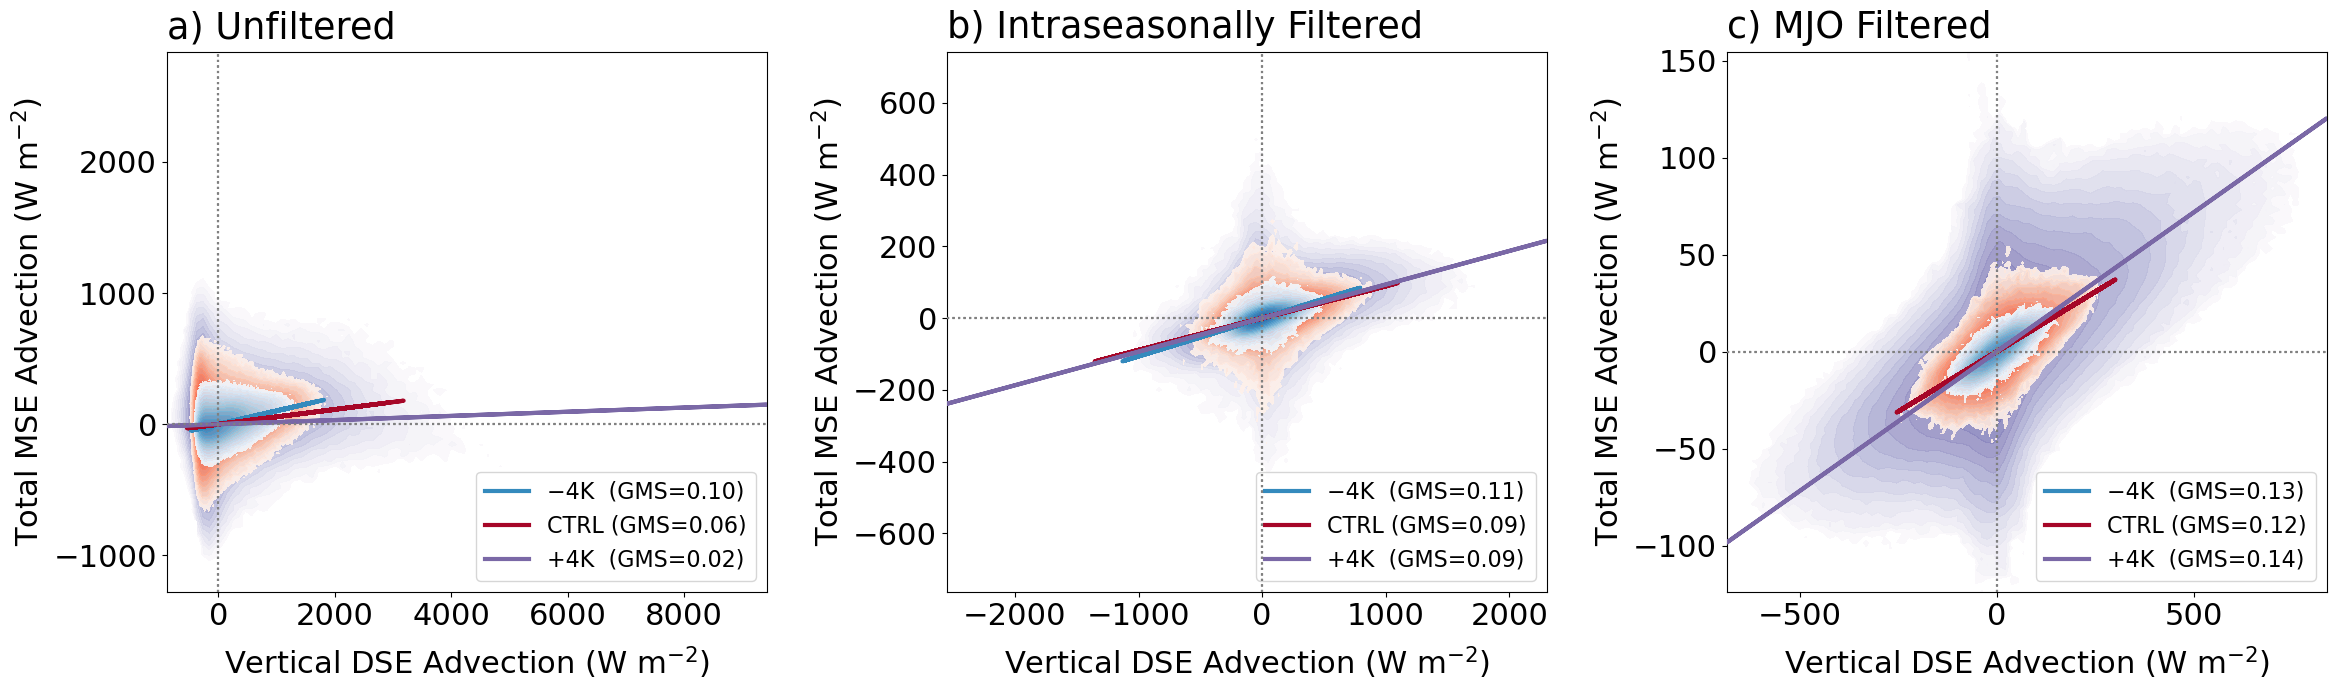

In [79]:
savefig = False
recalculate = True

component_to_plot = 'Total'

latitude_bounds = xr.DataArray(
    [[-5, -10, -15], [5, 10, 15]],
    # [[-30, -30, -30], [30, 30, 30]],
    # [[-15, -15, -15], [15, 15, 15]],
    dims=["bound", "experiment"],
    coords={"bound":['lower', 'upper'], "experiment": experiments_array}
)

experiment_cmaps = {}
experiment_cmaps['-4K'] = 'Blues'
experiment_cmaps['0K'] = 'Reds'
experiment_cmaps['4K'] = 'Purples'

all_variables_dict = {
    'Unfiltered': multi_experiment_GMS_variables,
    'Intraseasonally Filtered': multi_experiment_intraseasonally_filtered_GMS_variables,
    'MJO Filtered': multi_experiment_mjo_filtered_GMS_variables
}

# Mask and filter
lat_mask = (
    (multi_experiment_GMS_variables['Vertical MSE Advection'].lat >= latitude_bounds.sel(bound='lower')) &
    (multi_experiment_GMS_variables['Vertical MSE Advection'].lat <= latitude_bounds.sel(bound='upper'))
)

if 'denominator' not in locals() or recalculate:
    denominator, numerator, slope, intercept = {}, {}, {}, {}
    for dict_name, dict_values  in all_variables_dict.items():
        denominator[dict_name] = dict_values['Vertical DSE Advection'].where(lat_mask, drop=True).stack(grid_points=(['time', 'lat', 'lon']))
        denominator[dict_name] = standardize_data(denominator[dict_name], dim='grid_points', unit_variance = False)

        numerator[dict_name] = dict_values[f'{component_to_plot} MSE Advection'].where(lat_mask, drop=True).stack(grid_points=(['time', 'lat', 'lon']))
        numerator[dict_name] = standardize_data(numerator[dict_name], dim='grid_points', unit_variance = False)

        slope[dict_name] = xr.zeros_like(experiments_array).astype('float64')
        intercept[dict_name] = xr.zeros_like(experiments_array).astype('float64')
        for experiment_index, experiment in enumerate(experiments_list):
            slope[dict_name][experiment_index], intercept[dict_name][experiment_index] = np.polyfit(
                y=numerator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'),
                x=denominator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'),
                deg=1
            )

fontsize = 22
plt.rcParams.update({'font.size':fontsize})
fig = plt.figure(figsize=(24, 6))
gs = fig.add_gridspec(1, 3, wspace=0.3, width_ratios=[1, 1, 1])
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95)

axes_list = []
axes_list.append(fig.add_subplot(gs[0]))
axes_list.append(fig.add_subplot(gs[1]))
axes_list.append(fig.add_subplot(gs[2]))

for ax_index, (ax, (dict_name, dict_values))  in enumerate(zip(axes_list, all_variables_dict.items())):
    ax.set_title(f'{string.ascii_letters[ax_index]}) {dict_name}', loc='left', pad=10)
    for index, experiment in enumerate(experiments_list):

        counts,xbins,ybins = np.histogram2d(
            x=denominator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'),
            y=numerator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'),
            bins=[100, 100],
        )
        im = ax.contourf(
            np.log10(counts.transpose()),
            # counts.transpose(),
            extent=[xbins[0],xbins[-1],ybins[0],ybins[-1]],
            cmap=experiment_cmaps[experiment],
            # levels = np.linspace(10, np.nanmax(counts), 21),
            levels=np.linspace(np.log10(10), 6, 21),
            alpha=0.9,
            zorder = 4-index
        )
        ax.plot(
                denominator[dict_name].sel(experiment=experiment),
                (slope[dict_name]*denominator[dict_name]+intercept[dict_name]).sel(experiment=experiment),
                color=bmh_colors(index+1),
                lw=3,
                label=f"{experiments_array.sel(experiment=experiment)['name'].item():<4} (GMS={slope[dict_name].sel(experiment=experiment):>1.2f})",
                zorder=10,
            )
        ax.axhline(y=0, color='gray', ls=':', zorder=10)
        ax.axvline(x=0, color='gray', ls=':', zorder=10)
        # ax.set_ylim(-500, 500)

    ax.set_xlabel(r'Vertical DSE Advection (W m$^{-2}$)', labelpad=10)
    ax.set_ylabel(rf'{component_to_plot} MSE Advection (W m$^{{{-2}}}$)', labelpad=5)
    ax.legend(fontsize=16, loc='lower right')

# Unfiltered
# axes_list[0].set_xlim(-1000, 4250)
# axes_list[0].set_xticks(np.arange(-1000, 5000, 1000))
# axes_list[0].set_ylim(-500, 500)

# # Intraseasonally Filtered
# axes_list[1].set_xlim(-1300, 1500)
# axes_list[1].set_xticks(np.arange(-1300, 1500+700, 700))
# axes_list[1].set_ylim(-215, 215)
# axes_list[1].set_yticks(np.arange(-200, 300, 100))

# # MJO Filtered
# axes_list[2].set_xlim(-700, 900)
# axes_list[2].set_xticks(np.arange(-700, 900+400, 400))
# axes_list[2].set_ylim(-105, 105)
# axes_list[2].set_yticks(np.arange(-100, 125, 25))

# Save figure
output_filename = f"Zero Centered {component_to_plot} GMS Constituents Scatter Plot - Log(Histogram)"
print(f"Output directory: {aquaplanet_output_directory}/gross_moist_stability_analysis/")
print(f"Output filename: {output_filename}")
if savefig:
    print(f"{f'Saving...':<{str_width-1}}", end="")
    plt.savefig(
        f"{aquaplanet_output_directory}/gross_moist_stability_analysis/{output_filename}.png",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")
    plt.show()

/glade/derecho/scratch/sressel/tmp/ipykernel_115400/2370202053.py:95: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_115400/2370202053.py:95: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_115400/2370202053.py:95: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_115400/2370202053.py:95: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_115400/2370202053.py:95: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_115400/2370202053.py:95: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_115400/2370202053.py:95: Runtim

Output directory: /glade/u/home/sressel/thesis-work/python/aquaplanet_analysis/output//gross_moist_stability_analysis/
Output filename: Zero Centered Horizontal GMS Constituents Multi-Experiment Log(Histogram)
Not Saving


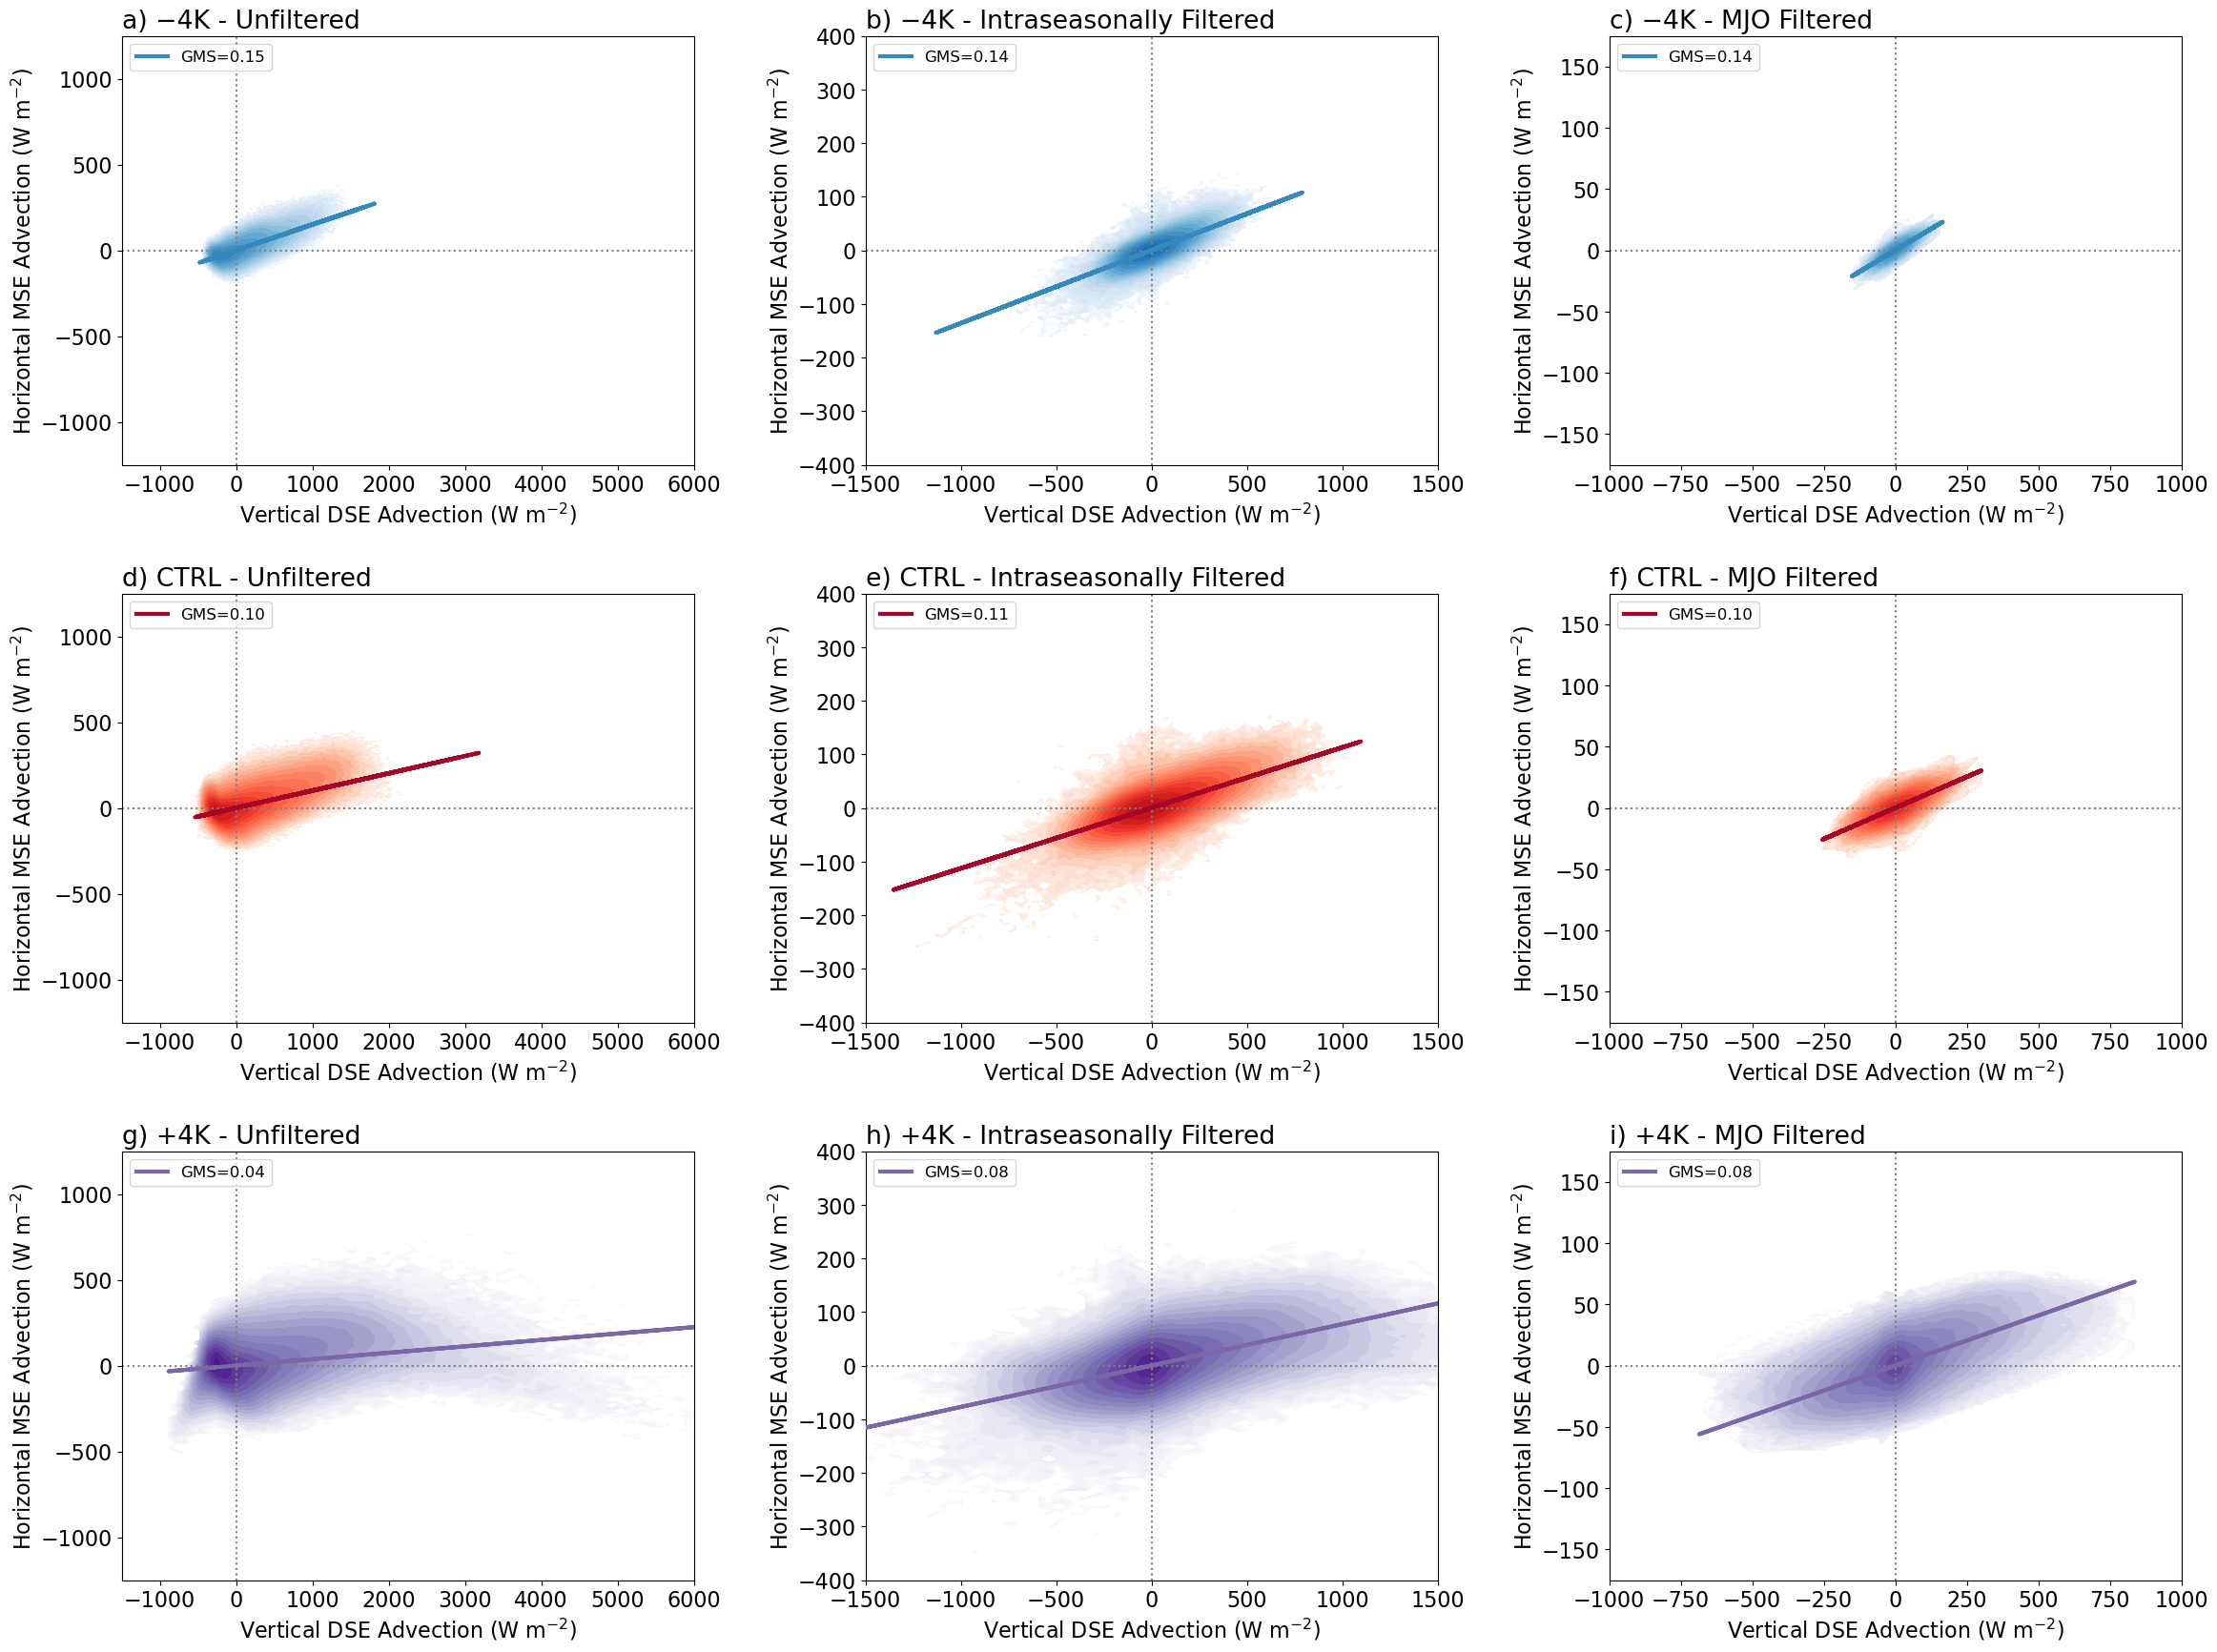

In [8]:
savefig = False
recalculate = False
seed = 235913091
random.seed(seed)
sample_points = 10000

latitude_bounds = xr.DataArray(
    [[-5, -10, -15], [5, 10, 15]],
    dims=["bound", "experiment"],
    coords={"bound":['lower', 'upper'], "experiment": experiments_array}
)
experiment_cmaps = {}
experiment_cmaps['-4K'] = 'Blues'
experiment_cmaps['0K'] = 'Reds'
experiment_cmaps['4K'] = 'Purples'

component_to_plot = 'Horizontal'

all_variables_dict = {
    'Unfiltered': multi_experiment_GMS_variables,
    'Intraseasonally Filtered': multi_experiment_intraseasonally_filtered_GMS_variables,
    'MJO Filtered': multi_experiment_mjo_filtered_GMS_variables
}

# Mask and filter
lat_mask = (
    (multi_experiment_GMS_variables['Vertical MSE Advection'].lat >= latitude_bounds.sel(bound='lower')) &
    (multi_experiment_GMS_variables['Vertical MSE Advection'].lat <= latitude_bounds.sel(bound='upper'))
)

if 'denominator' not in locals() or recalculate:
    denominator, numerator, slope, intercept = {}, {}, {}, {}
    for dict_name, dict_values  in all_variables_dict.items():
        denominator[dict_name] = dict_values['Vertical DSE Advection'].where(lat_mask, drop=True).stack(grid_points=(['time', 'lat', 'lon']))
        denominator[dict_name] = standardize_data(denominator[dict_name], dim='grid_points', unit_variance = False)

        numerator[dict_name] = dict_values[f'{component_to_plot} MSE Advection'].where(lat_mask, drop=True).stack(grid_points=(['time', 'lat', 'lon']))
        numerator[dict_name] = standardize_data(numerator[dict_name], dim='grid_points', unit_variance = False)

        slope[dict_name] = xr.zeros_like(experiments_array).astype('float64')
        intercept[dict_name] = xr.zeros_like(experiments_array).astype('float64')
        for experiment_index, experiment in enumerate(experiments_list):
            slope[dict_name][experiment_index], intercept[dict_name][experiment_index] = np.polyfit(
                y=numerator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'),
                x=denominator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'),
                deg=1
            )

fontsize = 16
plt.rcParams.update({'font.size':fontsize})
fig = plt.figure(figsize=(24, 18))
gs = fig.add_gridspec(3, 3, wspace=0.3, hspace=0.3, width_ratios=[1, 1, 1])
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95)

axes_list = []
axes_list.append(fig.add_subplot(gs[0,0]))
axes_list.append(fig.add_subplot(gs[0,1]))
axes_list.append(fig.add_subplot(gs[0,2]))
axes_list.append(fig.add_subplot(gs[1,0]))
axes_list.append(fig.add_subplot(gs[1,1]))
axes_list.append(fig.add_subplot(gs[1,2]))
axes_list.append(fig.add_subplot(gs[2,0]))
axes_list.append(fig.add_subplot(gs[2,1]))
axes_list.append(fig.add_subplot(gs[2,2]))

# for ax_index, (ax, (dict_name, dict_values))  in enumerate(zip(axes_list, all_variables_dict.items())):
for var_index, (dict_name, dict_values) in enumerate(all_variables_dict.items()):
    for experiment_index, experiment in enumerate(experiments_list):
        # ax_index = 3*var_index + experiment_index
        ax_index = 3*experiment_index + var_index

        # random_sample = random.sample(range(0, len(denominator[dict_name].sel(experiment=experiment).dropna(dim='grid_points')) + 1), sample_points)
        # sample_percentage = len(random_sample)/len(denominator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'))

        # axes_list[ax_index].scatter(
        #     x=denominator[dict_name].sel(experiment=experiment).dropna(dim='grid_points')[::100],
        #     y=numerator[dict_name].sel(experiment=experiment).dropna(dim='grid_points')[::100],
        #     color=bmh_colors(experiment_index+1),
        #     alpha=0.5
        # )
        # sns.kdeplot(
        #     ax=ax,
        #     x=denominator[dict_name].sel(experiment=experiment).dropna(dim='grid_points')[random_sample],
        #     y=numerator[dict_name].sel(experiment=experiment).dropna(dim='grid_points')[random_sample],
        #     fill=True,
        #     color=bmh_colors(index+1),
        #     alpha=0.75
        # )
        counts,xbins,ybins = np.histogram2d(
            x=denominator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'),
            y=numerator[dict_name].sel(experiment=experiment).dropna(dim='grid_points'),
            bins=[100, 100],
        )
        im = axes_list[ax_index].contourf(
            np.log10(counts.transpose()),
            # counts.transpose(),
            extent=[xbins[0],xbins[-1],ybins[0],ybins[-1]],
            cmap=experiment_cmaps[experiment],
            # levels = np.linspace(10, np.nanmax(counts), 21),
            levels=np.linspace(0.1, 6, 21),
            alpha=1.0
        )
        axes_list[ax_index].plot(
                denominator[dict_name].sel(experiment=experiment),
                (slope[dict_name]*denominator[dict_name]+intercept[dict_name]).sel(experiment=experiment),
                color=bmh_colors(experiment_index+1),
                lw=3,
                label=f"GMS={slope[dict_name].sel(experiment=experiment):>1.2f}",
                zorder=10,
            )

        if var_index == 0:
            axes_list[ax_index].set_xlim(-1500, 6000)
            # axes_list[ax_index].set_ylim(-500, 500)
            axes_list[ax_index].set_ylim(-1250, 1250)

        elif var_index == 1:
            axes_list[ax_index].set_xlim(-1500, 1500)
            # axes_list[ax_index].set_ylim(-250, 250)
            axes_list[ax_index].set_ylim(-400, 400)

        else:
            axes_list[ax_index].set_xlim(-1000, 1000)
            # axes_list[ax_index].set_ylim(-150, 150)
            axes_list[ax_index].set_ylim(-175, 175)

        axes_list[ax_index].set_xlabel(r'Vertical DSE Advection (W m$^{-2}$)')
        axes_list[ax_index].set_ylabel(rf'{component_to_plot} MSE Advection (W m$^{{{-2}}}$)')
        axes_list[ax_index].legend(fontsize=12, loc='upper left')
        axes_list[ax_index].axhline(y=0, color='gray', ls=':')
        axes_list[ax_index].axvline(x=0, color='gray', ls=':')
        axes_list[ax_index].set_title(
            (
                f"{string.ascii_letters[ax_index]}) "
                f"{experiments_array.sel(experiment=experiment)['name'].item()} - "
                f"{dict_name}"
            ),
            loc='left'
        )

# axes_list[0].set_title(
#     (
#         f'a) {component_to_plot} GMS Constituents'
#         +(f", (Plot: {100*sample_percentage:0.1f}% Sample)" if sample_percentage < 1 else "")
#     ),
#     loc='left'
# )

output_filename = f"Zero Centered {component_to_plot} GMS Constituents Multi-Experiment Log(Histogram)"
print(f"Output directory: {aquaplanet_output_directory}/gross_moist_stability_analysis/")
print(f"Output filename: {output_filename}")
if savefig:
    print(f"{f'Saving...':<{str_width-1}}", end="")
    plt.savefig(
        f"{aquaplanet_output_directory}/gross_moist_stability_analysis/{output_filename}.png",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")
    plt.show()

Text(0.5, 1.0, 'Vertical')

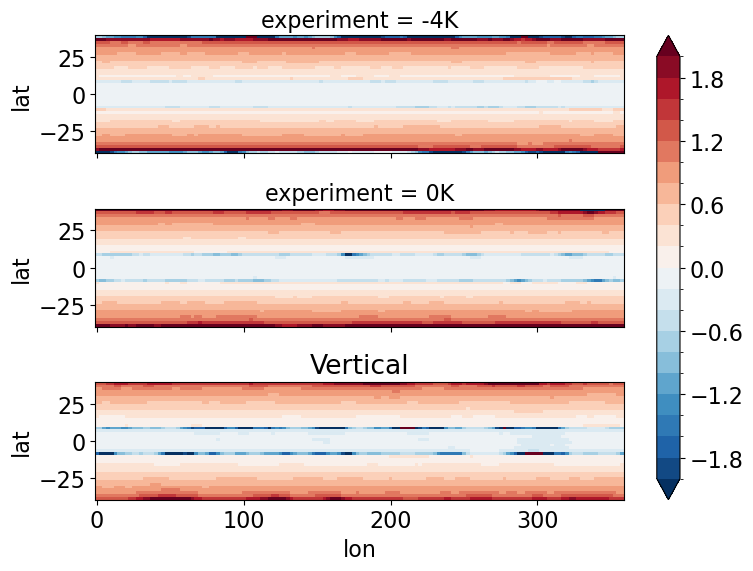

In [107]:
component_to_plot = 'Vertical'
(
    multi_experiment_GMS_variables[f'{component_to_plot} MSE Advection'].mean(dim='time')
    / multi_experiment_GMS_variables['Vertical DSE Advection'].mean(dim='time')
).plot(x='lon', y='lat', row='experiment', levels=np.linspace(-2, 2, 21), extend='both', figsize=(8,6), aspect='equal')
plt.title(f"{component_to_plot}")

## Calclate Convective Adjustment Timescale

In [31]:
reload_variables = False

if not 'multi_experiment_variables_subset' in locals() or reload_variables:
    multi_experiment_variables_subset = load_multi_experiment_processed_data(
        ['Precipitation', 'Column Water Vapor'],
        # ['Chikira alpha'],
        'subset'
    )
else:
    multi_experiment_variables_subset = load_multi_experiment_processed_data(
        # variables_to_load,
        ['Precipitation', 'Column Water Vapor'],
        'subset',
        multi_experiment_variables_subset,
        False
    )

          Loading subset data           
(1/2) Precipitation...                  
----------------------------------------
Loading data...
    Experiment: -4K                    ✔
    Experiment: 0K                     ✔
    Experiment: 4K                     ✔
Concatenating data...                  ✔
(2/2) Column Water Vapor...             
----------------------------------------
Loading data...
    Experiment: -4K                    ✔
    Experiment: 0K                     ✔
    Experiment: 4K                     ✔
Concatenating data...                  ✔
----------------------------------------
Data Loaded


/glade/derecho/scratch/sressel/tmp/ipykernel_21931/4199458298.py:67: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_21931/4199458298.py:67: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_21931/4199458298.py:67: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts.transpose()),


Output directory: /glade/u/home/sressel/thesis-work/python/aquaplanet_analysis/output//gross_moist_stability_analysis/
Output file: PRCP-CWV_ALL_LON_convective_adjustment_timescale
Not Saving


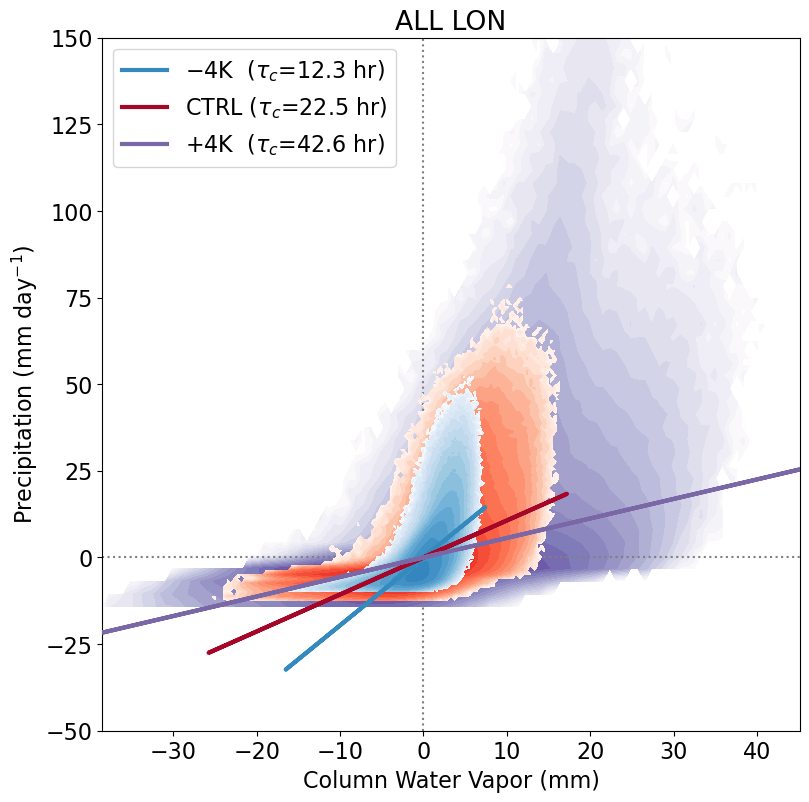

In [51]:
savefig=False
# longitude_bounds = (179, 181)

latitude_bounds = {}
latitude_bounds['-4K'] = (-5, 5)
latitude_bounds['0K'] = (-10, 10)
latitude_bounds['4K'] = (-15, 15)


# seed = 235913091
# random.seed(seed)
# random_sample = random.sample(range(0, len(flat_cwv) + 1), 1000)

convective_adjustment_timescale, slope, intercept = {}, {}, {}
[fig, ax] = plt.subplots(1, 1, figsize=(9,9))
for index, experiment in enumerate(experiments_list):

    standardized_column_water_vapor = standardize_data(
            multi_experiment_variables_subset['Column Water Vapor'],
            dim='time',
            unit_variance=False
        ).sel(experiment=experiment, lat=slice(*latitude_bounds[experiment]))

    standardized_precipitation = standardize_data(
            multi_experiment_variables_subset['Precipitation'],
            dim='time',
            unit_variance=False
        ).sel(experiment=experiment, lat=slice(*latitude_bounds[experiment]))

    flat_cwv = standardized_column_water_vapor.values.flatten()
    flat_precip = standardized_precipitation.values.flatten()

    slope[experiment], intercept[experiment] = np.polyfit(
            y=flat_precip,
            x=flat_cwv,
            deg=1
        )
    convective_adjustment_timescale[experiment] = 24/slope[experiment]

    # Plot
    ax.set_title(
        # f"({tick_labeller([longitude_bounds[0]], 'lon')[0]}"
        # f"-{tick_labeller([longitude_bounds[1]], 'lon')[0]})"
        "ALL LON"
        # f"{tick_labeller([180], 'lon')[0]}"
    )
    # sns.kdeplot(
    #     ax=ax,
    #     x=flat_cwv[random_sample],
    #     y=flat_precip[random_sample],
    #     fill=True,
    #     color=bmh_colors(index+1),
    #     alpha=0.9
    # )
    # ax.scatter(
    #     x=flat_cwv[random_sample],
    #     y=flat_precip[random_sample],
    #     color=bmh_colors(index+1),
    #     alpha=0.5
    # )
    counts,xbins,ybins = np.histogram2d(
        x=flat_cwv,
        y=flat_precip,
        bins=[100, 100],
    )
    im = ax.contourf(
        np.log10(counts.transpose()),
        # counts.transpose(),
        extent=[xbins[0],xbins[-1],ybins[0],ybins[-1]],
        cmap=experiment_cmaps[experiment],
        # levels = np.linspace(10, np.nanmax(counts), 21),
        levels=np.linspace(0.1, 6, 21),
        alpha=1.0,
        zorder = 4-index
    )
    ax.plot(
            flat_cwv,
            slope[experiment]*flat_cwv+intercept[experiment],
            # marker='o',
            color=bmh_colors(index+1),
            # color='lightgray',
            # edgecolor='k',
            lw=3,
            # mfc=bmh_colors(index+1),
            # mec='k',
            # mew=0.2,
            # lw=4,
            # alpha=0.5,
            zorder=10,
            label=(
            rf"{f'{experiments_array.sel(experiment=experiment)['name'].item()}':<4}"
            rf" ($\tau_c$={convective_adjustment_timescale[experiment]:>1.1f} hr)"
            ),
    )

ax.axhline(y=0, color='gray', ls=':')
ax.axvline(x=0, color='gray', ls=':')

ax.set_ylabel(r'Precipitation (mm day$^{-1}$)')
ax.set_xlabel(r'Column Water Vapor (mm)')
# ax.set_xlim(-25, 25)
# ax.set_ylim(-25, 25)
# ax.set_xticks(np.arange(-25, 30, 5))
# ax.set_yticks(np.arange(-25, 30, 5))

ax.legend(loc='upper left')
ax.set_ylim(-50, 150)

output_filename = (
    "PRCP-CWV_ALL_LON_convective_adjustment_timescale"
)
print(f"Output directory: {aquaplanet_output_directory}/gross_moist_stability_analysis/")
print(f"Output file: {output_filename}")
if savefig:
    print(f"{f'Saving...':<{str_width-1}}", end="")
    plt.savefig(
        f"{aquaplanet_output_directory}/gross_moist_stability_analysis/{output_filename}.png",
        dpi=500,
        bbox_inches="tight"
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")
    plt.show()

In [52]:
convective_adjustment_timescale

{'-4K': 12.262774017406793, '0K': 22.489343155784884, '4K': 42.638754845321884}